In [1]:
import numpy as np

In [2]:
import torch
import emcee
from px2cosmo import fm as FM 
from px2cosmo import util as UT

In [3]:
import corner as DFM
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

# load mock observations

In [6]:
omega_true = np.load("/Users/ch54662/data/px2cosmo/mock/omega_true.npy")
X_obs_z14 = np.load("/Users/ch54662/data/px2cosmo/mock/X_obs_z14.npy")
X_obs_z11 = np.load("/Users/ch54662/data/px2cosmo/mock/X_obs_z11.npy")
X_obs_z9 = np.load("/Users/ch54662/data/px2cosmo/mock/X_obs_z9.npy")

In [8]:
# z=14
_X_obs_z14 = torch.tensor(X_obs_z14[:,:2].astype(np.float32))#.to('mps')
_sig_obs_z14 = torch.tensor(X_obs_z14[:,2:].astype(np.float32))#.to('mps')
_log1pN_obs_z14 = torch.tensor(np.log1p(X_obs_z14.shape[0]).astype(np.float32))#.to('mps')

# z=11
_X_obs_z11 = torch.tensor(X_obs_z11[:,:2].astype(np.float32)).to('mps')
_sig_obs_z11 = torch.tensor(X_obs_z11[:,2:].astype(np.float32)).to('mps')
_log1pN_obs_z11 = torch.tensor(np.log1p(X_obs_z11.shape[0]).astype(np.float32)).to('mps')

# z=9
_X_obs_z9 = torch.tensor(X_obs_z9[:,:2].astype(np.float32)).to('mps')
_sig_obs_z9 = torch.tensor(X_obs_z9[:,2:].astype(np.float32)).to('mps')
_log1pN_obs_z9 = torch.tensor(np.log1p(X_obs_z9.shape[0]).astype(np.float32)).to('mps')

In [21]:
z_meds = [8.512603493733069, 10.54828960289537, 13.864237408667474]

# load $p(N|\omega, S)$ and $p(X|\sigma, \omega, S)$ estimates

In [9]:
#p_omegat_log1pN_z11 = torch.load('/Users/ch54662/data/px2cosmo/mock/q_omegat_log1pN_z11.pt', weights_only=False)
#p_omegat_log1pN_z9 = torch.load('/Users/ch54662/data/px2cosmo/mock/q_omegat_log1pN_z9.pt', weights_only=False)
#p_omegat_log1pN_z7 = torch.load('/Users/ch54662/data/px2cosmo/mock/q_omegat_log1pN_z7.pt', weights_only=False)
p_omegat_log1pN_z14 = torch.load('/Users/ch54662/data/px2cosmo/mock/ndes/q_omegat_log1pN_z14/q_omegat_log1pN_z14.28.pt', weights_only=False)
p_omegat_log1pN_z11 = torch.load('/Users/ch54662/data/px2cosmo/mock/ndes/nde/q_omegat_log1pN_z11/q_omegat_log1pN_z11.30.pt', weights_only=False)
p_omegat_log1pN_z9 = torch.load('/Users/ch54662/data/px2cosmo/mock/ndes/nde/q_omegat_log1pN_z9/q_omegat_log1pN_z9.34.pt', weights_only=False)

In [49]:
p_X_omegasig_S_z14 = torch.load('/Users/ch54662/data/px2cosmo/mock/ndes/q_X_omegasig_z14_batch50/q_X_omegasig_z14_batch50.2.pt', weights_only=False)
p_X_omegasig_S_z11 = torch.load('/Users/ch54662/data/px2cosmo/mock/ndes/nde/q_X_omegasig_z11/q_X_omegasig_z11.20.pt', weights_only=False)
p_X_omegasig_S_z9 = torch.load('/Users/ch54662/data/px2cosmo/mock/ndes/q_X_omegasig_z9_down/q_X_omegasig_z9_down.14.pt', weights_only=False)

# set up prior and posterior

In [11]:
def log_prior(omega): 
    alpha, beta, gamma, Muv_s, phi_amp = omega
    if -1.8 < alpha < -1.5 and -1.8 < beta < -1.2 and -0.4 < gamma < 0 and -22 < Muv_s < -18 and 1e-3 < phi_amp < 1e-2: 
        return 0.
    return -np.inf

In [12]:
bounds = np.array([[-1.8, -1.5], [-1.8, -1.2], [-0.4, 0.], [-22., -18.], [1e-3, 1e-2]])

# MCMC
First just the Poisson terms

In [16]:
def log_posterior_poisson_z14(omega, silent=True): 
    lp = log_prior(omega) # prior 
    if not np.isfinite(lp): return -np.inf
    
    # poisson term of the likelihood
    omega_t = UT.inv_cdf_transform(omega, bounds.T)
    _omega_t = torch.tensor(omega_t.astype(np.float32))#.to('mps')
    return p_omegat_log1pN_z14.log_prob(_omega_t, _log1pN_obs_z14, norm_posterior=False).item()

def log_posterior_poisson_z11(omega, silent=True): 
    lp = log_prior(omega) # prior 
    if not np.isfinite(lp): return -np.inf
    
    # poisson term of the likelihood
    omega_t = UT.inv_cdf_transform(omega, bounds.T)
    _omega_t = torch.tensor(omega_t.astype(np.float32)).to('mps')
    return p_omegat_log1pN_z11.log_prob(_omega_t, _log1pN_obs_z11, norm_posterior=False).item()

def log_posterior_poisson_z9(omega, silent=True): 
    lp = log_prior(omega) # prior 
    if not np.isfinite(lp): return -np.inf
    
    # poisson term of the likelihood
    omega_t = UT.inv_cdf_transform(omega, bounds.T)
    _omega_t = torch.tensor(omega_t.astype(np.float32)).to('mps')
    return p_omegat_log1pN_z9.log_prob(_omega_t, _log1pN_obs_z9, norm_posterior=False).item()    

def log_posterior_poisson(omega, silent=True): 
    lp = log_prior(omega) # prior 
    if not np.isfinite(lp): return -np.inf
    
    # poisson term of the likelihood
    omega_t = UT.inv_cdf_transform(omega, bounds.T)
    _omega_t = torch.tensor(omega_t.astype(np.float32))
    logp_poisson0 = p_omegat_log1pN_z14.log_prob(_omega_t, 
                                                _log1pN_obs_z14, 
                                                norm_posterior=False).item()
    logp_poisson1 = p_omegat_log1pN_z11.log_prob(_omega_t.to('mps'), 
                                                _log1pN_obs_z11, 
                                                norm_posterior=False).item()
    logp_poisson2 = p_omegat_log1pN_z9.log_prob(_omega_t.to('mps'), 
                                                _log1pN_obs_z9, 
                                                norm_posterior=False).item()
    return logp_poisson0 + logp_poisson1 + logp_poisson2

In [17]:
ndim, nwalkers = 5, 10
p0 = np.array([
    np.random.uniform(-1.8, -1.5, nwalkers),
    np.random.uniform(-1.8, -1.2, nwalkers),
    np.random.uniform(-0.4,  0.0, nwalkers),
    np.random.uniform(-22.,  -18., nwalkers),
    np.random.uniform(1e-3,  1e-2, nwalkers),
]).T

In [ ]:
sampler_poisson = emcee.EnsembleSampler(nwalkers, ndim, log_posterior_poisson)
_ = sampler_poisson.run_mcmc(p0, 10000, progress=True)

In [24]:
sampler_poisson_z14 = emcee.EnsembleSampler(nwalkers, ndim, log_posterior_poisson_z14)
_ = sampler_poisson_z14.run_mcmc(p0, 10000, progress=True)

sampler_poisson_z11 = emcee.EnsembleSampler(nwalkers, ndim, log_posterior_poisson_z11)
_ = sampler_poisson_z11.run_mcmc(p0, 10000, progress=True)

sampler_poisson_z9 = emcee.EnsembleSampler(nwalkers, ndim, log_posterior_poisson_z9)
_ = sampler_poisson_z9.run_mcmc(p0, 10000, progress=True)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [03:05<00:00, 53.87it/s]


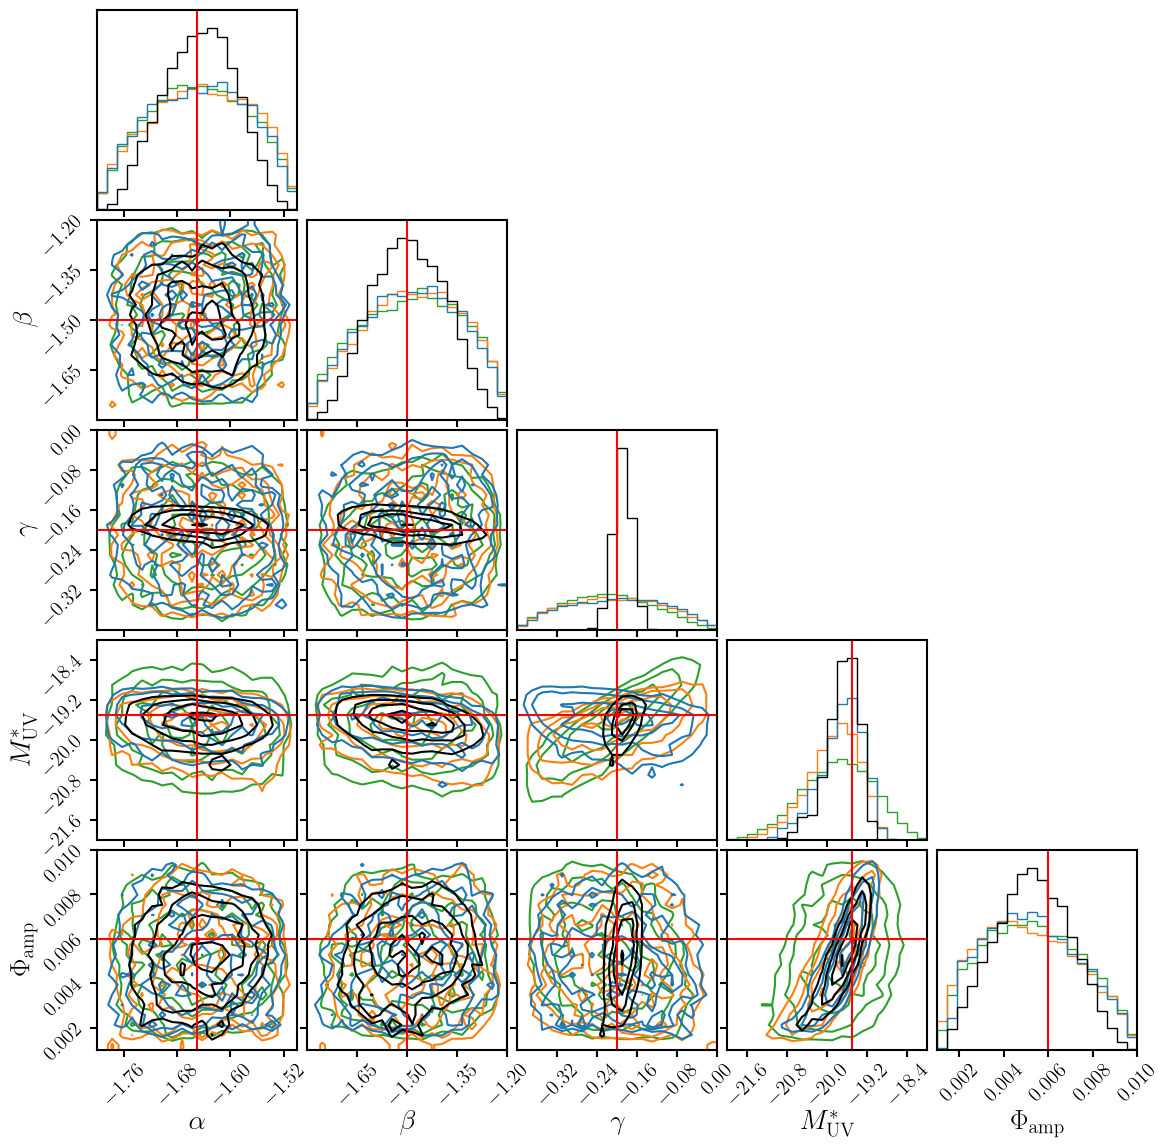

In [27]:
fig = DFM.corner(sampler_poisson_z14.flatchain[5000:,:], color='C2', plot_density=False, plot_datapoints=False,
                 range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)], 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20})
fig = DFM.corner(sampler_poisson_z11.flatchain[5000:,:], color='C1', plot_density=False, plot_datapoints=False,
                 range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)], 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20}, fig=fig)
fig = DFM.corner(sampler_poisson_z9.flatchain[5000:,:], color='C0', plot_density=False, plot_datapoints=False,
                 range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)], 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20}, fig=fig)
fig = DFM.corner(sampler_poisson.flatchain[5000:,:], color='k', plot_density=False, plot_datapoints=False,
                 range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)], 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20}, fig=fig)
DFM.overplot_points(fig, [omega_true], color='red')
DFM.overplot_lines(fig, omega_true, color='red')

individual sample constraints

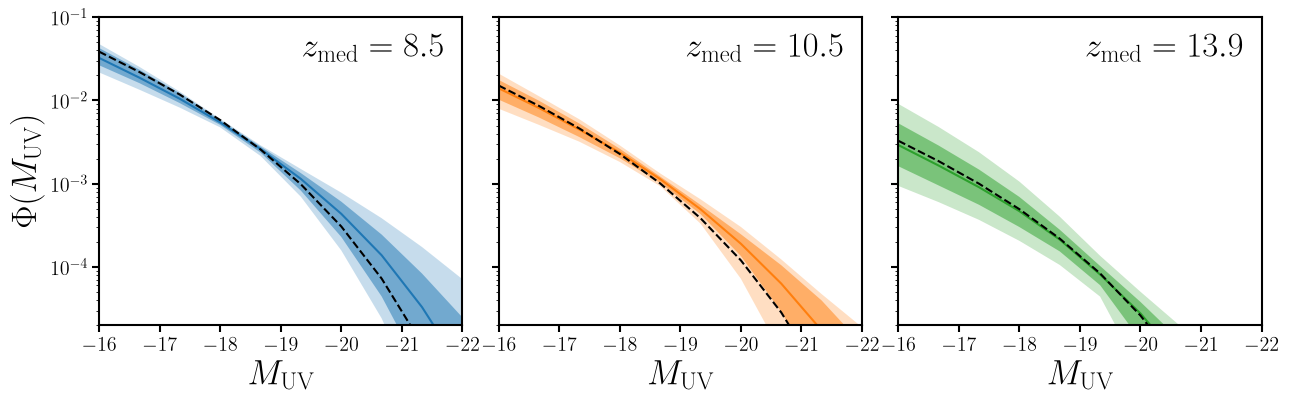

In [33]:
Muv_bin = np.linspace(-16, -22, 10)

fig = plt.figure(figsize=(15,4))
for i, z in enumerate(z_meds): 
    sub = fig.add_subplot(1,3,i+1)

    _sampler = [sampler_poisson_z9, sampler_poisson_z11, sampler_poisson_z14][i]
    LFs = [] 
    for _om in _sampler.flatchain[-1000:,:]: 
        LFs.append(_om[-1] * UT.LF(Muv_bin, z, _om[:-1]))
    q00, q0, q1, q2, q22 = np.quantile(np.array(LFs), [0.025, 0.16, 0.5, 0.84, 0.975], axis=0)

    sub.fill_between(Muv_bin, q00, q22, edgecolor='none', facecolor='C%i' % i, alpha=0.25)
    sub.fill_between(Muv_bin, q0, q2, edgecolor='none', facecolor='C%i' % i, alpha=0.5)
    sub.plot(Muv_bin, q1, color='C%i' % i)

    sub.plot(Muv_bin, omega_true[-1] * UT.LF(Muv_bin, z, omega_true[:-1]), c='k', ls='--')

    sub.text(0.95, 0.95, r'$z_{\rm med}=%.1f$' % z, fontsize=25, transform=sub.transAxes, ha='right', va='top')    
    sub.set_xlabel(r'$M_{\rm UV}$', fontsize=25)
    sub.set_xlim(-16, -22)
    if i == 0: sub.set_ylabel(r'$\Phi(M_{\rm UV})$', fontsize=25)
    else: sub.tick_params(labelleft=False)
    sub.set_yscale('log') 
    sub.set_ylim(2e-5, 1e-1)

fig.subplots_adjust(wspace=0.1)

combined constraints

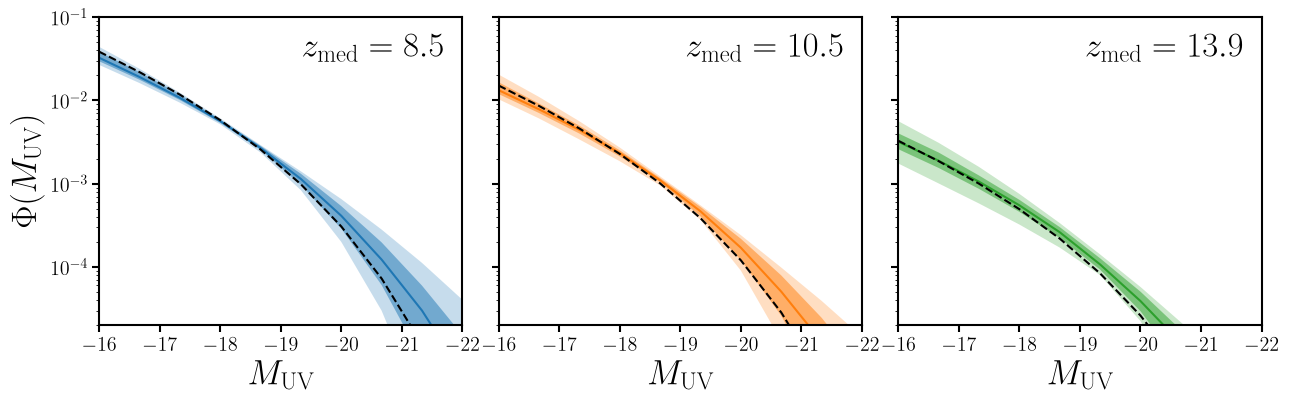

In [34]:
Muv_bin = np.linspace(-16, -22, 10)

fig = plt.figure(figsize=(15,4))
for i, z in enumerate(z_meds): 
    sub = fig.add_subplot(1,3,i+1)

    _sampler = sampler_poisson #[sampler_poisson_z9, sampler_poisson_z11, sampler_poisson_z14][i]
    LFs = [] 
    for _om in _sampler.flatchain[-1000:,:]: 
        LFs.append(_om[-1] * UT.LF(Muv_bin, z, _om[:-1]))
    q00, q0, q1, q2, q22 = np.quantile(np.array(LFs), [0.025, 0.16, 0.5, 0.84, 0.975], axis=0)

    sub.fill_between(Muv_bin, q00, q22, edgecolor='none', facecolor='C%i' % i, alpha=0.25)
    sub.fill_between(Muv_bin, q0, q2, edgecolor='none', facecolor='C%i' % i, alpha=0.5)
    sub.plot(Muv_bin, q1, color='C%i' % i)

    sub.plot(Muv_bin, omega_true[-1] * UT.LF(Muv_bin, z, omega_true[:-1]), c='k', ls='--')

    sub.text(0.95, 0.95, r'$z_{\rm med}=%.1f$' % z, fontsize=25, transform=sub.transAxes, ha='right', va='top')    
    sub.set_xlabel(r'$M_{\rm UV}$', fontsize=25)
    sub.set_xlim(-16, -22)
    if i == 0: sub.set_ylabel(r'$\Phi(M_{\rm UV})$', fontsize=25)
    else: sub.tick_params(labelleft=False)
    sub.set_yscale('log') 
    sub.set_ylim(2e-5, 1e-1)

fig.subplots_adjust(wspace=0.1)

Now let's incorporate the full likelihood. 

# Full likelihood $z=14$ sample
First for the $z=14$ sample alone

In [36]:
def log_posterior_z14(omega, silent=True): 
    lp = log_prior(omega) # prior 
    if not np.isfinite(lp): return -np.inf
    
    # poisson term of the likelihood
    omega_t = UT.inv_cdf_transform(omega, bounds.T)
    _omega_t = torch.tensor(omega_t.astype(np.float32))#.to('mps')
    logp_poisson = p_omegat_log1pN_z14.log_prob(_omega_t, _log1pN_obs_z14, norm_posterior=False).item()

    # log likelihood
    _omega = torch.tensor(omega[:-1].astype(np.float32))#.to('mps')
    _omegasig = torch.cat([_omega.expand(_X_obs_z14.shape[0], -1), _sig_obs_z14], dim=1)
    logp = p_X_omegasig_S_z14.log_prob_batched(_X_obs_z14, _omegasig, norm_posterior=False).sum().item()

    if not silent: print(logp_poisson, logp)
    return logp_poisson + logp    

In [37]:
ndim, nwalkers = 5, 10
p0 = np.array([
    np.random.uniform(-1.8, -1.5, nwalkers),
    np.random.uniform(-1.8, -1.2, nwalkers),
    np.random.uniform(-0.4,  0.0, nwalkers),
    np.random.uniform(-22.,  -18., nwalkers),
    np.random.uniform(1e-3,  1e-2, nwalkers),
]).T

In [38]:
sampler_fullz14 = emcee.EnsembleSampler(nwalkers, ndim, log_posterior_z14)
_ = sampler_fullz14.run_mcmc(p0, 10000, progress=True)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [08:03<00:00, 20.68it/s]


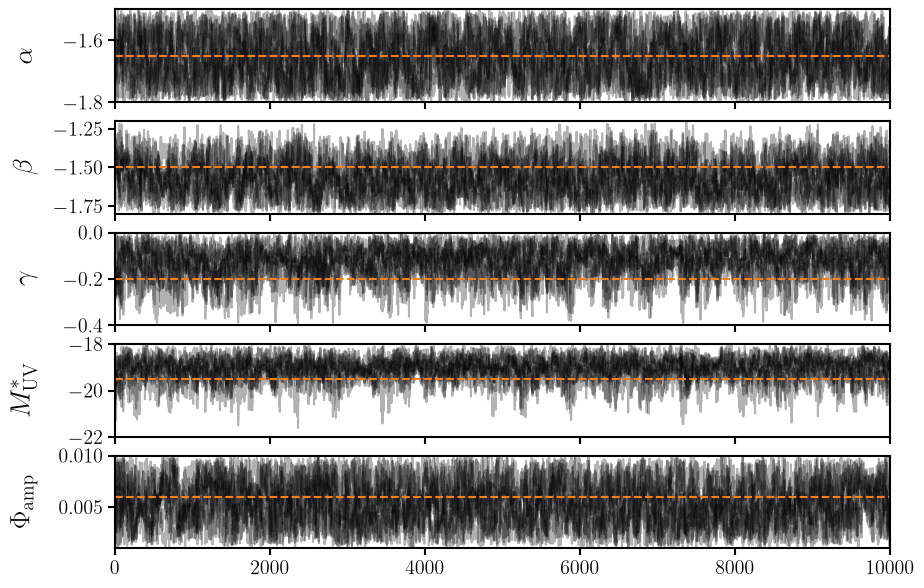

In [39]:
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
samples = sampler_fullz14.get_chain()
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.plot([0, samples.shape[0]], [omega_true[i], omega_true[i]], c='C1', ls='--')
    ax.set_xlim(0, len(samples))
    ax.set_ylabel([r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'][i], fontsize=20)
    ax.yaxis.set_label_coords(-0.1, 0.5)
    ax.set_ylim([(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)][i])

In [ ]:
bench_z14 = np.load('/Users/ch54662/data/px2cosmo/mock/benchmark/mcmc_benchmark_z14.npy')

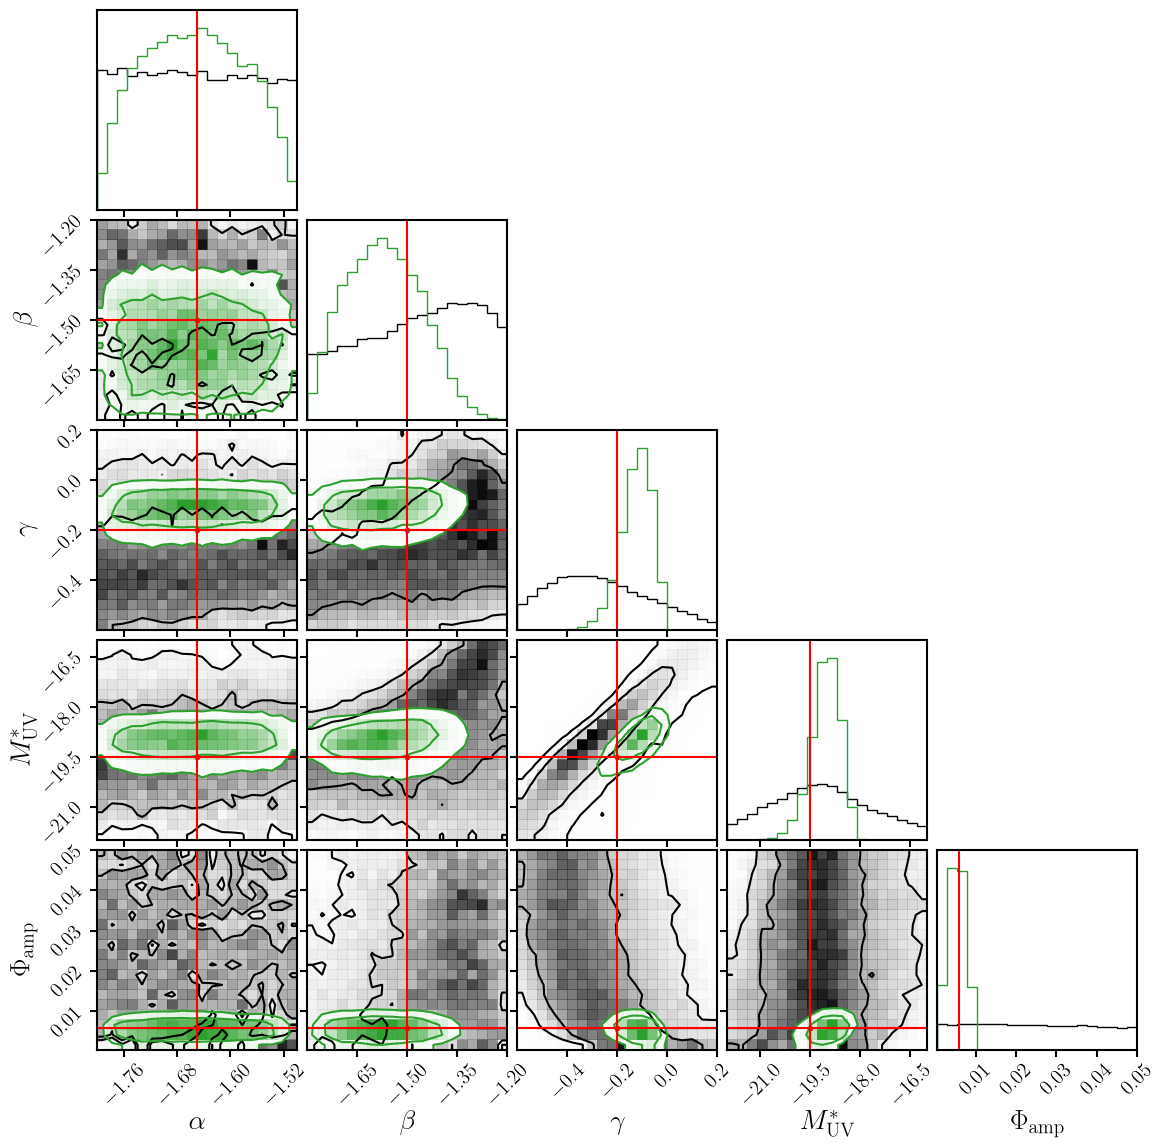

In [161]:
fig = DFM.corner(bench_z14, color='k', plot_datapoints=False, 
                 range=[(-1.8, -1.5), [-1.8, -1.2], [-0.6, 0.2], [-22., -16], [5e-4, 5e-2]], 
                 hist_kwargs={'density': True}, levels=[0.68, 0.95], 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20})
fig = DFM.corner(sampler_fullz14.flatchain[5000:,:], color='C2', plot_datapoints=False,
                 range=[(-1.8, -1.5), [-1.8, -1.2], [-0.6, 0.2], [-22., -16], [5e-4, 5e-2]], 
                 hist_kwargs={'density': True}, levels=[0.68, 0.95], 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20}, 
                 fig=fig)
DFM.overplot_points(fig, [omega_true], color='red')
DFM.overplot_lines(fig, omega_true, color='red')

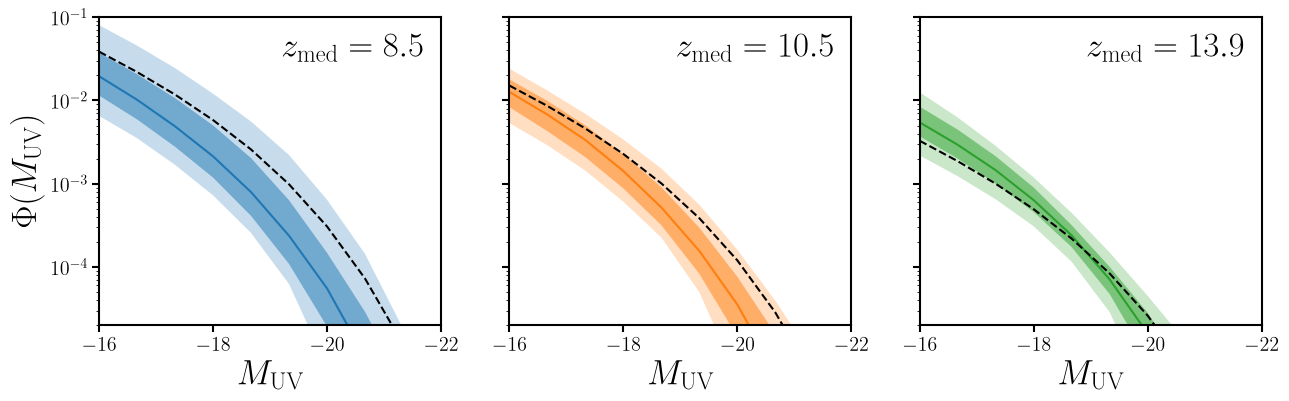

In [41]:
fig = plt.figure(figsize=(15,4))
for i, z in enumerate(z_meds): 
    sub = fig.add_subplot(1,3,i+1)

    LFs = [] 
    for _om in sampler_fullz14.flatchain[-4000:,:][::2]: 
        LFs.append(_om[-1] * UT.LF(Muv_bin, z, _om[:-1]))
    q00, q0, q1, q2, q22 = np.quantile(np.array(LFs), [0.025, 0.16, 0.5, 0.84, 0.975], axis=0)

    sub.fill_between(Muv_bin, q00, q22, edgecolor='none', facecolor='C%i' % i, alpha=0.25)
    sub.fill_between(Muv_bin, q0, q2, edgecolor='none', facecolor='C%i' % i, alpha=0.5)
    sub.plot(Muv_bin, q1, color='C%i' % i)

    sub.plot(Muv_bin, omega_true[-1] * UT.LF(Muv_bin, z, omega_true[:-1]), c='k', ls='--')

    sub.text(0.95, 0.95, r'$z_{\rm med}=%.1f$' % z, fontsize=25, transform=sub.transAxes, ha='right', va='top')    
    sub.set_xlabel(r'$M_{\rm UV}$', fontsize=25)
    sub.set_xlim(-16, -22)
    if i == 0: sub.set_ylabel(r'$\Phi(M_{\rm UV})$', fontsize=25)
    else: sub.tick_params(labelleft=False)
    sub.set_yscale('log') 
    sub.set_ylim(2e-5, 1e-1)

# Full Likelihood $z=11$

In [50]:
def log_posterior_z11(omega, silent=True): 
    lp = log_prior(omega) # prior 
    if not np.isfinite(lp): return -np.inf
    
    # poisson term of the likelihood
    omega_t = UT.inv_cdf_transform(omega, bounds.T)
    _omega_t = torch.tensor(omega_t.astype(np.float32)).to('mps')
    logp_poisson = p_omegat_log1pN_z11.log_prob(_omega_t, _log1pN_obs_z11, norm_posterior=False).item()

    # log likelihood
    _omega = torch.tensor(omega[:-1].astype(np.float32)).to('mps')
    _omegasig = torch.cat([_omega.expand(_X_obs_z11.shape[0], -1), _sig_obs_z11], dim=1)
    logp = p_X_omegasig_S_z11.log_prob_batched(_X_obs_z11, _omegasig, norm_posterior=False).sum().item()

    if not silent: print(logp_poisson, logp)
    return logp_poisson + logp    

In [51]:
ndim, nwalkers = 5, 10
p0 = np.array([
    np.random.uniform(-1.8, -1.5, nwalkers),
    np.random.uniform(-1.8, -1.2, nwalkers),
    np.random.uniform(-0.4,  0.0, nwalkers),
    np.random.uniform(-22.,  -18., nwalkers),
    np.random.uniform(1e-3,  1e-2, nwalkers),
]).T

sampler_fullz11 = emcee.EnsembleSampler(nwalkers, ndim, log_posterior_z11)
_ = sampler_fullz11.run_mcmc(p0, 10000, progress=True)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [10:46<00:00, 15.47it/s]


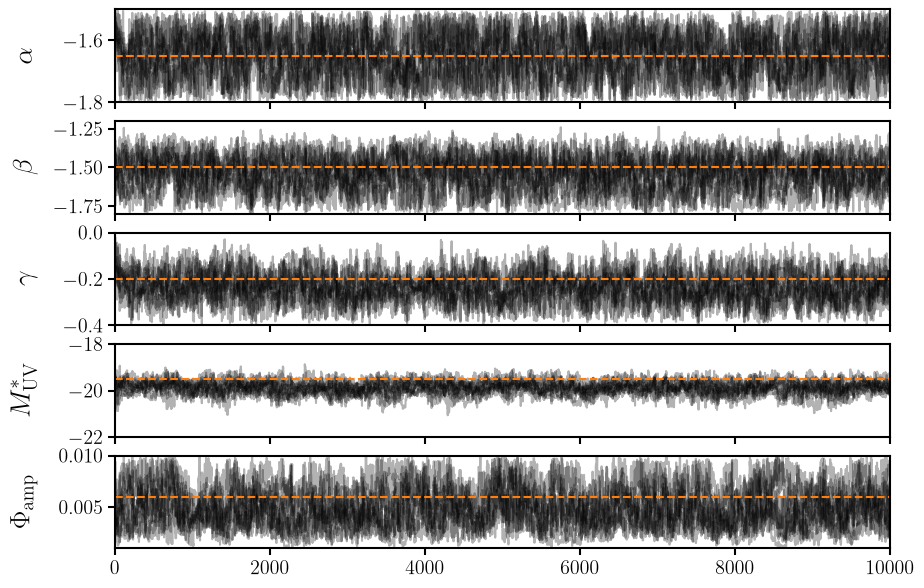

In [52]:
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
samples = sampler_fullz11.get_chain()
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.plot([0, samples.shape[0]], [omega_true[i], omega_true[i]], c='C1', ls='--')
    ax.set_xlim(0, len(samples))
    ax.set_ylabel([r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'][i], fontsize=20)
    ax.yaxis.set_label_coords(-0.1, 0.5)
    ax.set_ylim([(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)][i])

In [82]:
bench_z11 = np.load('/Users/ch54662/data/px2cosmo/mock/benchmark/mcmc_benchmark_z11.npy')

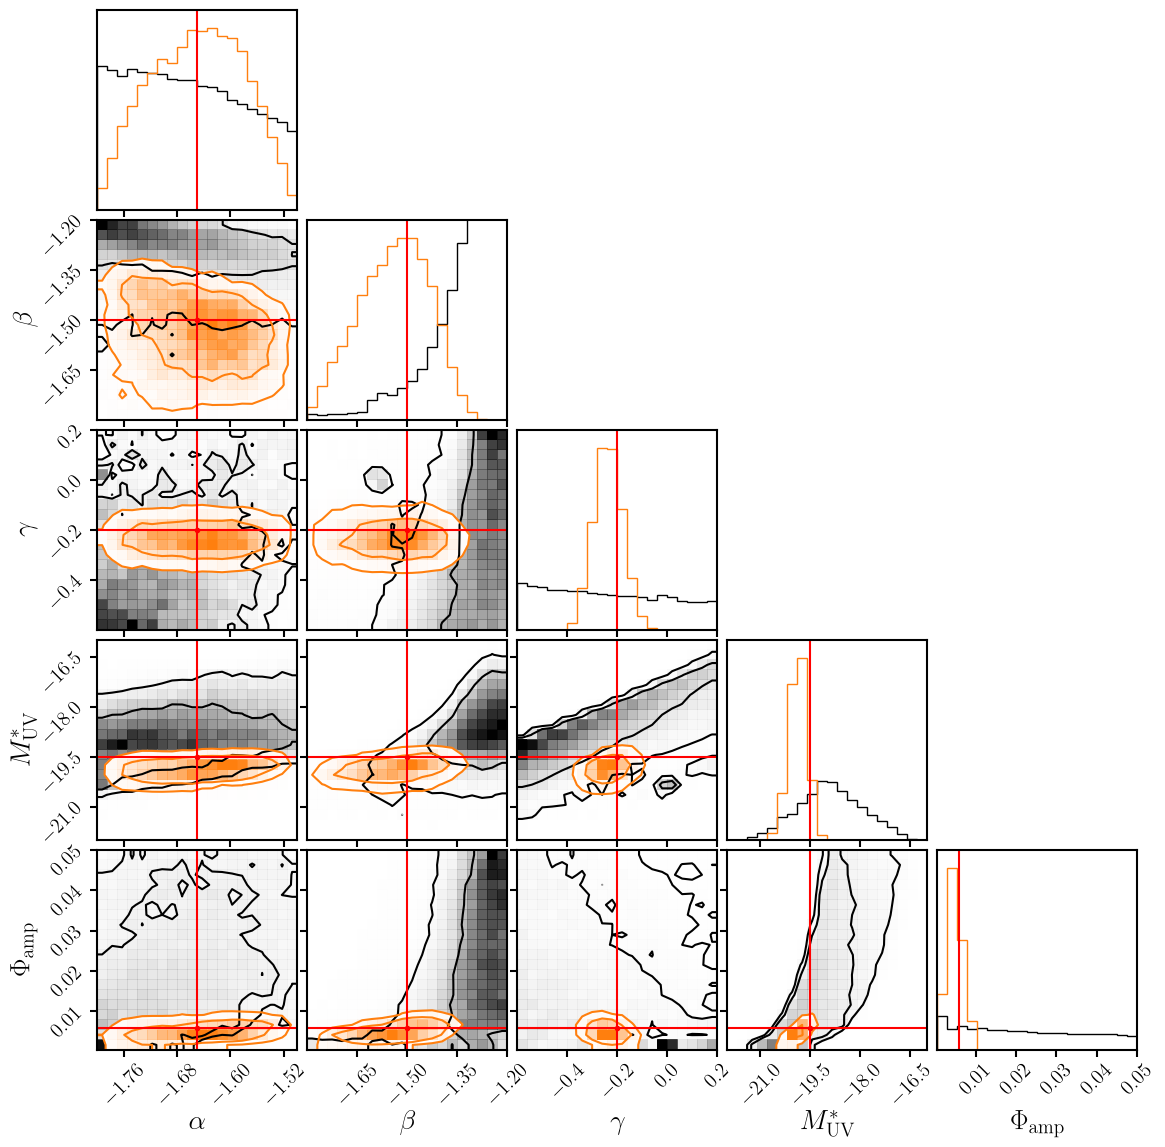

In [160]:
fig = DFM.corner(bench_z11, color='k', plot_datapoints=False, 
                 range=[(-1.8, -1.5), [-1.8, -1.2], [-0.6, 0.2], [-22., -16], [5e-4, 5e-2]], 
                 hist_kwargs={'density': True}, levels=[0.68, 0.95], 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20})
fig = DFM.corner(sampler_fullz11.flatchain[5000:,:], color='C1', plot_datapoints=False,
                 range=[(-1.8, -1.5), [-1.8, -1.2], [-0.6, 0.2], [-22., -16], [5e-4, 5e-2]], 
                 hist_kwargs={'density': True}, levels=[0.68, 0.95], 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20}, 
                 fig=fig)
DFM.overplot_points(fig, [omega_true], color='red')
DFM.overplot_lines(fig, omega_true, color='red')

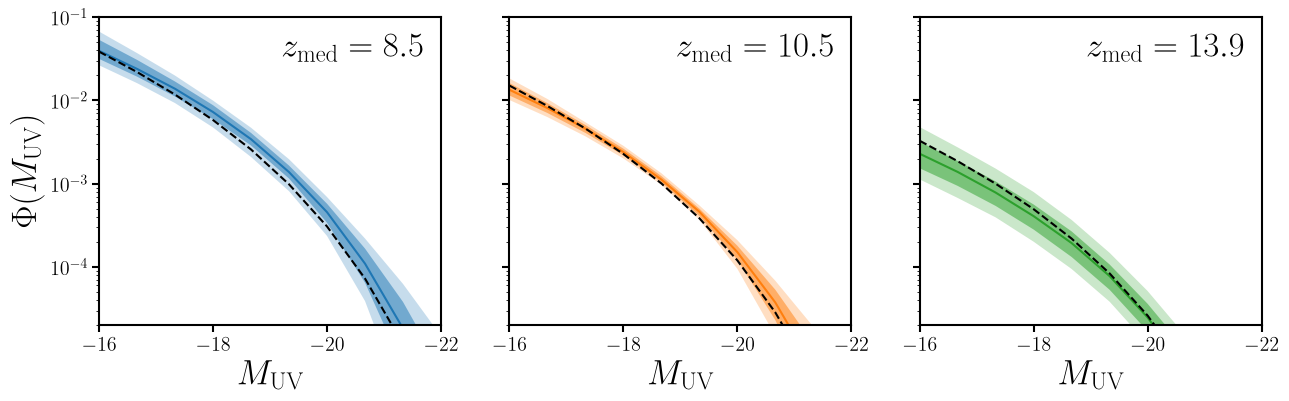

In [56]:
fig = plt.figure(figsize=(15,4))
for i, z in enumerate(z_meds): 
    sub = fig.add_subplot(1,3,i+1)

    LFs = [] 
    for _om in sampler_fullz11.flatchain[-4000:,:][::2]: 
        LFs.append(_om[-1] * UT.LF(Muv_bin, z, _om[:-1]))
    q00, q0, q1, q2, q22 = np.quantile(np.array(LFs), [0.025, 0.16, 0.5, 0.84, 0.975], axis=0)

    sub.fill_between(Muv_bin, q00, q22, edgecolor='none', facecolor='C%i' % i, alpha=0.25)
    sub.fill_between(Muv_bin, q0, q2, edgecolor='none', facecolor='C%i' % i, alpha=0.5)
    sub.plot(Muv_bin, q1, color='C%i' % i)

    sub.plot(Muv_bin, omega_true[-1] * UT.LF(Muv_bin, z, omega_true[:-1]), c='k', ls='--')

    sub.text(0.95, 0.95, r'$z_{\rm med}=%.1f$' % z, fontsize=25, transform=sub.transAxes, ha='right', va='top')    
    sub.set_xlabel(r'$M_{\rm UV}$', fontsize=25)
    sub.set_xlim(-16, -22)
    if i == 0: sub.set_ylabel(r'$\Phi(M_{\rm UV})$', fontsize=25)
    else: sub.tick_params(labelleft=False)
    sub.set_yscale('log') 
    sub.set_ylim(2e-5, 1e-1)

# $z=9$ only 

In [65]:
def log_posterior_z9(omega, silent=True): 
    lp = log_prior(omega) # prior 
    if not np.isfinite(lp): return -np.inf
    
    # poisson term of the likelihood
    omega_t = UT.inv_cdf_transform(omega, bounds.T)
    _omega_t = torch.tensor(omega_t.astype(np.float32)).to('mps')
    logp_poisson = p_omegat_log1pN_z9.log_prob(_omega_t, _log1pN_obs_z9, norm_posterior=False).item()

    # log likelihood
    _omega = torch.tensor(omega[:-1].astype(np.float32))#.to('mps')
    _omegasig = torch.cat([_omega.expand(_X_obs_z9.shape[0], -1), _sig_obs_z9.to('cpu')], dim=1)
    logp = p_X_omegasig_S_z9.log_prob_batched(_X_obs_z9.to('cpu'), _omegasig, norm_posterior=False).sum().item()

    if not silent: print(logp_poisson, logp)
    return logp_poisson + logp    

In [66]:
ndim, nwalkers = 5, 10
p0 = np.array([
    np.random.uniform(-1.8, -1.5, nwalkers),
    np.random.uniform(-1.8, -1.2, nwalkers),
    np.random.uniform(-0.4,  0.0, nwalkers),
    np.random.uniform(-22.,  -18., nwalkers),
    np.random.uniform(1e-3,  1e-2, nwalkers),
]).T

sampler_fullz9 = emcee.EnsembleSampler(nwalkers, ndim, log_posterior_z9)
_ = sampler_fullz9.run_mcmc(p0, 10000, progress=True)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [10:46<00:00, 15.47it/s]


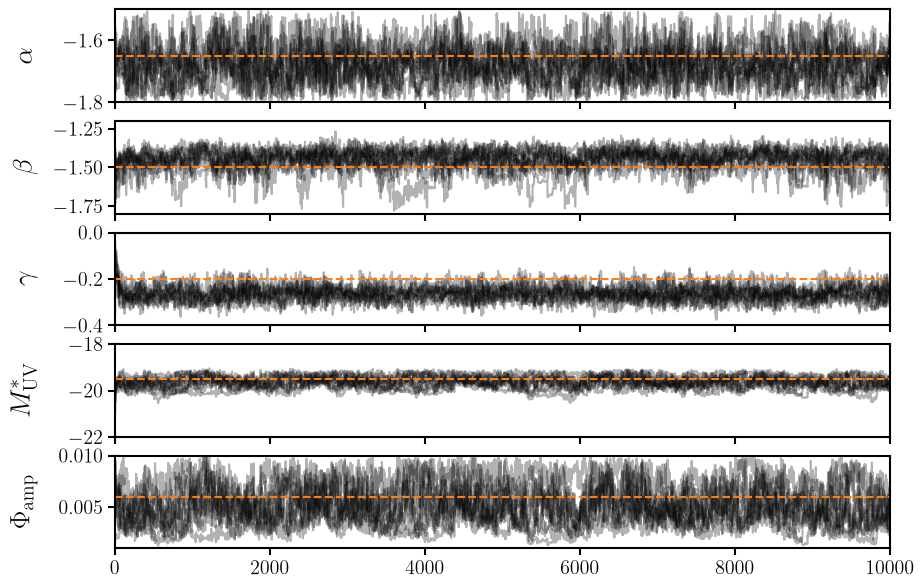

In [71]:
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
samples = sampler_fullz9.get_chain()
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.plot([0, samples.shape[0]], [omega_true[i], omega_true[i]], c='C1', ls='--')
    ax.set_xlim(0, len(samples))
    ax.set_ylabel([r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'][i], fontsize=20)
    ax.yaxis.set_label_coords(-0.1, 0.5)
    ax.set_ylim([(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)][i])

In [84]:
bench_z9 = np.load('/Users/ch54662/data/px2cosmo/mock/benchmark/mcmc_benchmark_z9.npy')

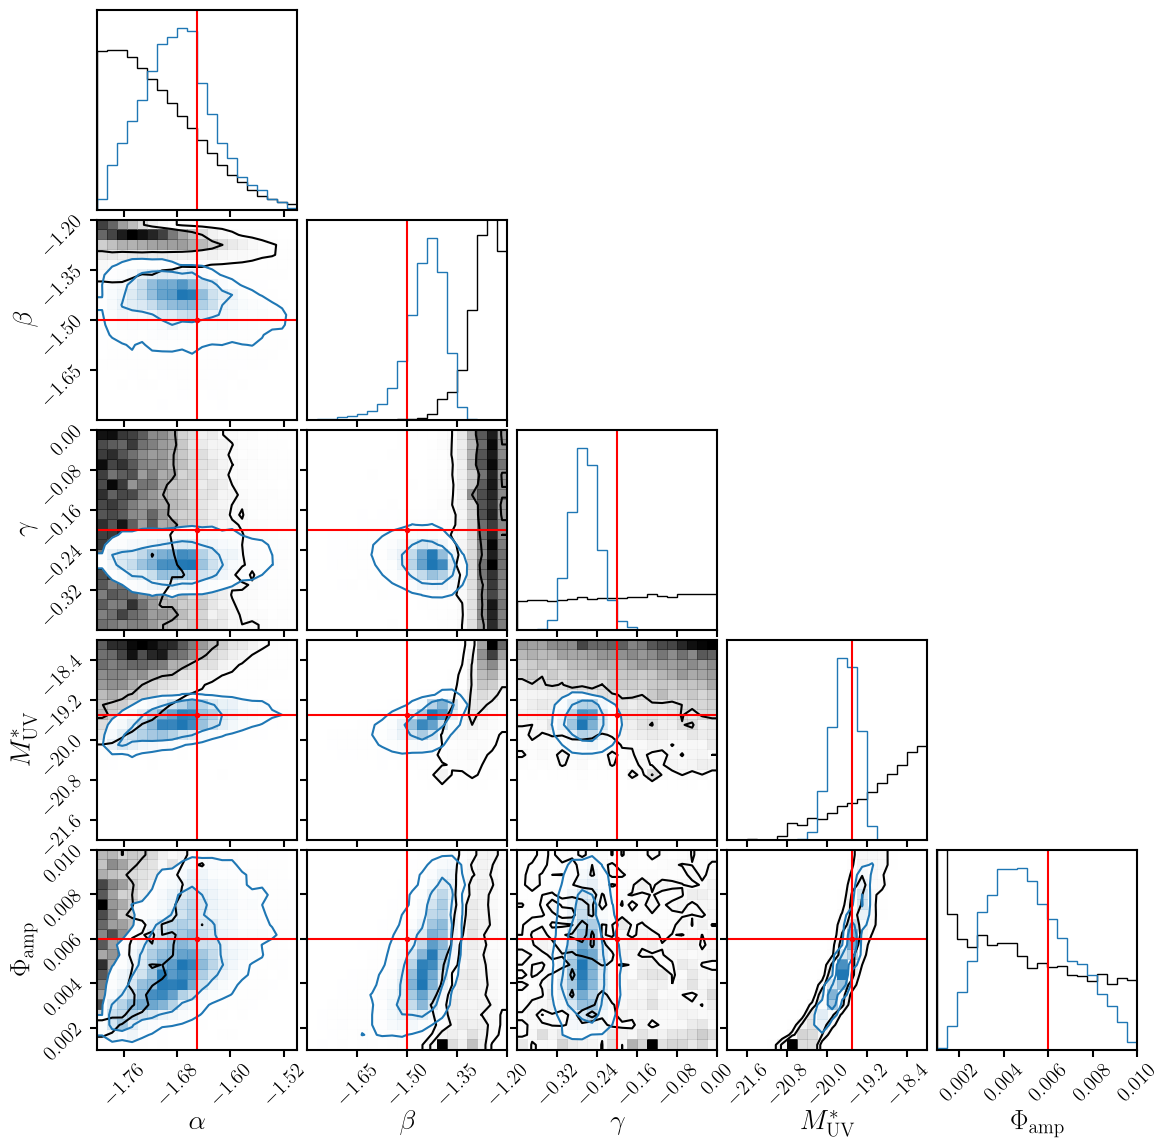

In [158]:
fig = DFM.corner(bench_z9, color='k', plot_datapoints=False, 
                 range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)],
                 #range=[[-2., -1.2], [-2., -1.2], [-0.6, 0.2], [-22., -16], [5e-4, 5e-2]], 
                 hist_kwargs={'density': True}, levels=[0.68, 0.95], 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20})
fig = DFM.corner(sampler_fullz9.flatchain[5000:,:], color='C0', plot_datapoints=False,
                 range=[(-1.8, -1.5), (-1.8, -1.2), (-0.4, 0.0), (-22, -18), (1e-3, 1e-2)],
                 #range=[[-2., -1.2], [-2., -1.2], [-0.6, 0.2], [-22., -16], [5e-4, 5e-2]], 
                 hist_kwargs={'density': True}, levels=[0.68, 0.95], 
                 labels=[r'$\alpha$', r'$\beta$', r'$\gamma$', r'$M_{\rm UV}^*$', r'$\Phi_{\rm amp}$'], label_kwargs={'fontsize': 20}, 
                 fig=fig)
DFM.overplot_points(fig, [omega_true], color='red')
DFM.overplot_lines(fig, omega_true, color='red')

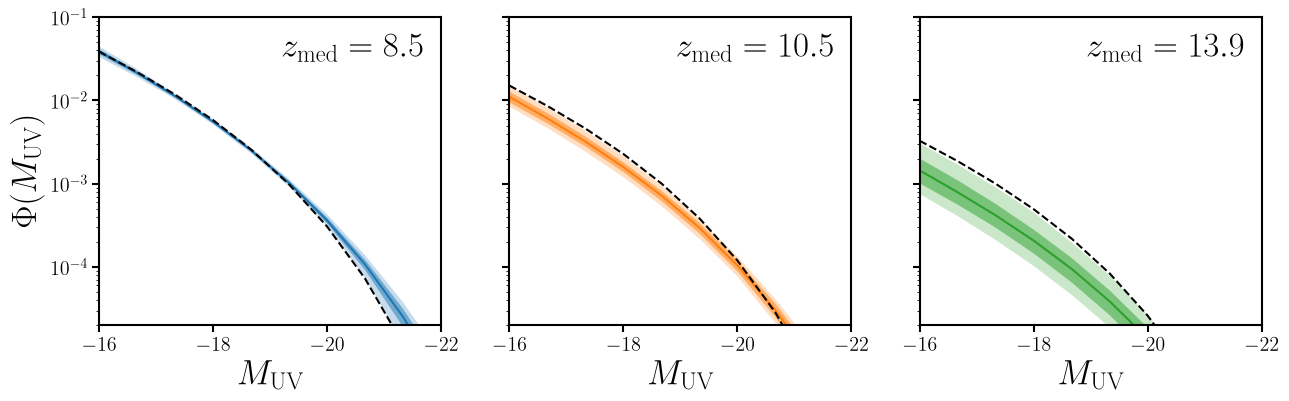

In [73]:
fig = plt.figure(figsize=(15,4))
for i, z in enumerate(z_meds): 
    sub = fig.add_subplot(1,3,i+1)

    LFs = [] 
    for _om in sampler_fullz9.flatchain[-4000:,:][::2]: 
        LFs.append(_om[-1] * UT.LF(Muv_bin, z, _om[:-1]))
    q00, q0, q1, q2, q22 = np.quantile(np.array(LFs), [0.025, 0.16, 0.5, 0.84, 0.975], axis=0)

    sub.fill_between(Muv_bin, q00, q22, edgecolor='none', facecolor='C%i' % i, alpha=0.25)
    sub.fill_between(Muv_bin, q0, q2, edgecolor='none', facecolor='C%i' % i, alpha=0.5)
    sub.plot(Muv_bin, q1, color='C%i' % i)

    sub.plot(Muv_bin, omega_true[-1] * UT.LF(Muv_bin, z, omega_true[:-1]), c='k', ls='--')

    sub.text(0.95, 0.95, r'$z_{\rm med}=%.1f$' % z, fontsize=25, transform=sub.transAxes, ha='right', va='top')    
    sub.set_xlabel(r'$M_{\rm UV}$', fontsize=25)
    sub.set_xlim(-16, -22)
    if i == 0: sub.set_ylabel(r'$\Phi(M_{\rm UV})$', fontsize=25)
    else: sub.tick_params(labelleft=False)
    sub.set_yscale('log') 
    sub.set_ylim(2e-5, 1e-1)

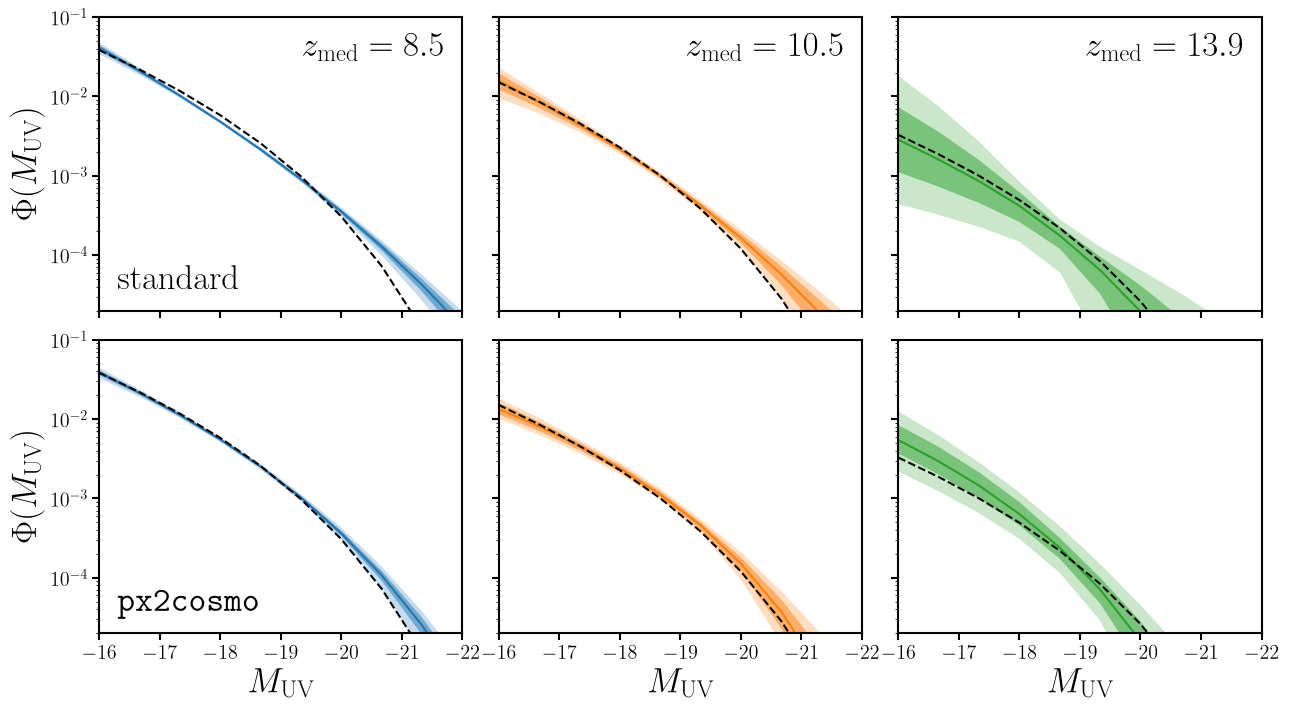

In [147]:
fig = plt.figure(figsize=(15,8))
for i, z in enumerate(z_meds): 
    sub = fig.add_subplot(2,3,i+1)

    _chain = [bench_z9, bench_z11, bench_z14][i]
    LFs = [] 
    for _om in _chain[::10]: 
        LFs.append(_om[-1] * UT.LF(Muv_bin, z, _om[:-1]))
    q00, q0, q1, q2, q22 = np.quantile(np.array(LFs), [0.025, 0.16, 0.5, 0.84, 0.975], axis=0)

    sub.fill_between(Muv_bin, q00, q22, edgecolor='none', facecolor='C%i' % i, alpha=0.25)
    sub.fill_between(Muv_bin, q0, q2, edgecolor='none', facecolor='C%i' % i, alpha=0.5)
    sub.plot(Muv_bin, q1, color='C%i' % i)

    sub.plot(Muv_bin, omega_true[-1] * UT.LF(Muv_bin, z, omega_true[:-1]), c='k', ls='--')

    sub.text(0.95, 0.95, r'$z_{\rm med}=%.1f$' % z, fontsize=25, transform=sub.transAxes, ha='right', va='top')    
    if i == 0: sub.text(0.05, 0.05, r'standard', fontsize=25, transform=sub.transAxes, ha='left', va='bottom')    
    sub.set_xlim(-16, -22)
    sub.tick_params(labelbottom=False)
    if i == 0: sub.set_ylabel(r'$\Phi(M_{\rm UV})$', fontsize=25)
    else: sub.tick_params(labelleft=False)
    sub.set_yscale('log') 
    sub.set_ylim(2e-5, 1e-1)

for i, z in enumerate(z_meds): 
    sub = fig.add_subplot(2,3,3+i+1)

    _sampler = [sampler_fullz9, sampler_fullz11, sampler_fullz14][i]
    LFs = [] 
    for _om in _sampler.flatchain[-4000:,:][::2]: 
        LFs.append(_om[-1] * UT.LF(Muv_bin, z, _om[:-1]))
    q00, q0, q1, q2, q22 = np.quantile(np.array(LFs), [0.025, 0.16, 0.5, 0.84, 0.975], axis=0)

    sub.fill_between(Muv_bin, q00, q22, edgecolor='none', facecolor='C%i' % i, alpha=0.25)
    sub.fill_between(Muv_bin, q0, q2, edgecolor='none', facecolor='C%i' % i, alpha=0.5)
    sub.plot(Muv_bin, q1, color='C%i' % i)

    sub.plot(Muv_bin, omega_true[-1] * UT.LF(Muv_bin, z, omega_true[:-1]), c='k', ls='--')

    #sub.text(0.95, 0.95, r'$z_{\rm med}=%.1f$' % z, fontsize=25, transform=sub.transAxes, ha='right', va='top')    
    if i == 0: sub.text(0.05, 0.05, r'$\mathtt{px2cosmo}$', fontsize=25, transform=sub.transAxes, ha='left', va='bottom')    
    sub.set_xlabel(r'$M_{\rm UV}$', fontsize=25)
    sub.set_xlim(-16, -22)
    if i == 0: sub.set_ylabel(r'$\Phi(M_{\rm UV})$', fontsize=25)
    else: sub.tick_params(labelleft=False)
    sub.set_yscale('log') 
    sub.set_ylim(2e-5, 1e-1)
fig.subplots_adjust(hspace=0.1, wspace=0.1)
fig.savefig('uvlf_popinf_comparison.pdf', bbox_inches='tight')

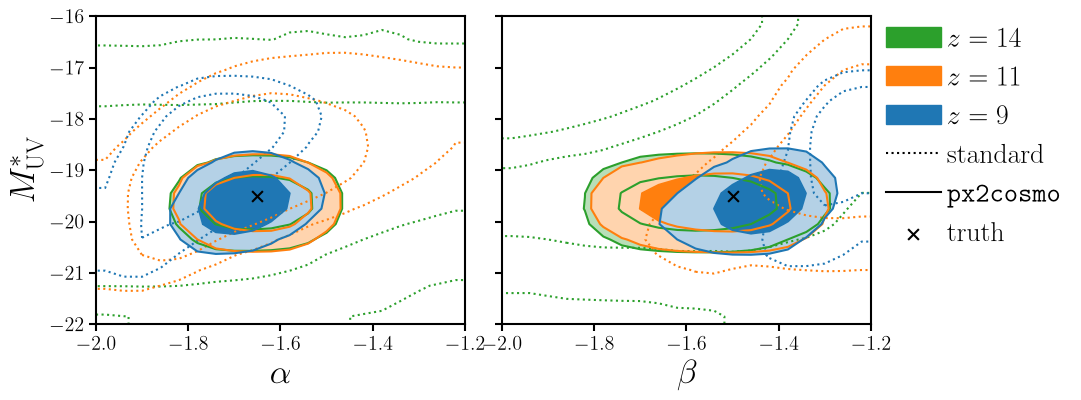

In [140]:
fig = plt.figure(figsize=(10,4))
sub = fig.add_subplot(121)
DFM.hist2d(bench_z14[:,0], bench_z14[:,3], color='C2', plot_datapoints=False, plot_density=False, ax=sub,
                 range=[[-2., -1.2], [-22., -16]], smooth=True, 
                 hist_kwargs={'density': True}, levels=[0.68, 0.95], 
                 contour_kwargs={'linestyle': ':'})
DFM.hist2d(bench_z11[:,0], bench_z11[:,3], color='C1', plot_datapoints=False, plot_density=False, ax=sub,
                 range=[[-2., -1.2], [-22., -16]], smooth=True, 
                 hist_kwargs={'density': True}, levels=[0.68, 0.95], 
                 contour_kwargs={'linestyle': ':'})
DFM.hist2d(bench_z9[:,0], bench_z9[:,3], color='C0', plot_datapoints=False, plot_density=False, ax=sub,
                 range=[[-2., -1.2], [-22., -16]], smooth=True, 
                 hist_kwargs={'density': True}, levels=[0.68, 0.95], 
                 contour_kwargs={'linestyle': ':'})
DFM.hist2d(sampler_fullz14.flatchain[5000:,0], sampler_fullz9.flatchain[5000:,3], color='C2', fill_contours=True, ax=sub,
                 range=[[-2., -1.2], [-22., -16]], smooth=True, 
                 hist_kwargs={'density': True}, levels=[0.68, 0.95])
DFM.hist2d(sampler_fullz11.flatchain[5000:,0], sampler_fullz9.flatchain[5000:,3], color='C1', fill_contours=True, ax=sub,
                 range=[[-2., -1.2], [-22., -16]], smooth=True, 
                 hist_kwargs={'density': True}, levels=[0.68, 0.95])
DFM.hist2d(sampler_fullz9.flatchain[5000:,0], sampler_fullz9.flatchain[5000:,3], color='C0', fill_contours=True, ax=sub,
                 range=[[-2., -1.2], [-22., -16]], smooth=True, 
                 hist_kwargs={'density': True}, levels=[0.68, 0.95])
sub.scatter([omega_true[0]], [omega_true[3]], color='k', marker='x', s=60)
sub.set_xlabel(r'$\alpha$', fontsize=25)
sub.set_ylabel(r'$M_{\rm UV}^*$', fontsize=25)

sub = fig.add_subplot(122)
DFM.hist2d(bench_z14[:,1], bench_z14[:,3], color='C2', plot_datapoints=False, plot_density=False, ax=sub,
                 range=[[-2., -1.2], [-22., -16]], smooth=True, 
                 hist_kwargs={'density': True}, levels=[0.68, 0.95], 
                 contour_kwargs={'linestyle': ':'})
DFM.hist2d(bench_z11[:,1], bench_z11[:,3], color='C1', plot_datapoints=False, plot_density=False, ax=sub,
                 range=[[-2., -1.2], [-22., -16]], smooth=True, 
                 hist_kwargs={'density': True}, levels=[0.68, 0.95], 
                 contour_kwargs={'linestyle': ':'})
DFM.hist2d(bench_z9[:,1], bench_z9[:,3], color='C0', plot_datapoints=False, plot_density=False, ax=sub,
                 range=[[-2., -1.2], [-22., -16]], smooth=True, 
                 hist_kwargs={'density': True}, levels=[0.68, 0.95], 
                 contour_kwargs={'linestyle': ':'})
DFM.hist2d(sampler_fullz14.flatchain[5000:,1], sampler_fullz9.flatchain[5000:,3], color='C2', fill_contours=True, ax=sub,
                 range=[[-2., -1.2], [-22., -16]], smooth=True, 
                 hist_kwargs={'density': True}, levels=[0.68, 0.95])
DFM.hist2d(sampler_fullz11.flatchain[5000:,1], sampler_fullz9.flatchain[5000:,3], color='C1', fill_contours=True, ax=sub,
                 range=[[-2., -1.2], [-22., -16]], smooth=True, 
                 hist_kwargs={'density': True}, levels=[0.68, 0.95])
DFM.hist2d(sampler_fullz9.flatchain[5000:,1], sampler_fullz9.flatchain[5000:,3], color='C0', fill_contours=True, ax=sub,
                 range=[[-2., -1.2], [-22., -16]], smooth=True, 
                 hist_kwargs={'density': True}, levels=[0.68, 0.95])


sub.fill_between([], [], [], color='C2', label='$z=14$')
sub.fill_between([], [], [], color='C1', label='$z=11$')
sub.fill_between([], [], [], color='C0', label='$z=9$')
sub.plot([], [], c='k', linestyle=':', label='standard')
sub.plot([], [], c='k', linestyle='-', label=r'$\mathtt{px2cosmo}$')
sub.scatter([omega_true[1]], [omega_true[3]], color='k', marker='x', s=60, label='truth')

sub.legend(loc='upper left', fontsize=20, handletextpad=0.2, bbox_to_anchor=(1.01, 1), borderaxespad=0)
sub.set_xlabel(r'$\beta$', fontsize=25)
_ = sub.set_yticklabels([])
fig.subplots_adjust(wspace=0.1)
fig.savefig("popinf_comparison.pdf", bbox_inches='tight') 